# INSTALL EXTENSIONS

In [7]:
!nvidia-smi

Tue Mar 24 20:16:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.99                 Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              4W /   30W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
import sys
print("Jupyter python path:", sys.executable)
print("Python ver:", sys.version)

Jupyter python path: D:\python stuff\Final\.venv\Scripts\python.exe
Python ver: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]


In [4]:
# Test if you can reach huggingface.co
import socket
try:
    socket.gethostbyname('huggingface.co')
    print("✅ Can resolve huggingface.co")
except:
    print("❌ Cannot resolve huggingface.co - DNS issue")

✅ Can resolve huggingface.co


In [ ]:
pip install google_play_scraper

In [ ]:
from google_play_scraper import reviews_all, reviews, Sort
import pandas as pd
from pathlib import Path

APP_ID = "id.bni.wondr"
SAVE_FILE = "all_reviews_wondr.csv"

def load_existing():
    """ Load data from CSV if exists, if not return empty DF. """
    if Path(SAVE_FILE).exists():
        df = pd.read_csv(SAVE_FILE)
        expected_cols = ["reviewID", "content", "at"]
        for col in expected_cols:
            if col not in df.columns:
                df[col] = None
        return df[expected_cols]
    else:
        return pd.DataFrame(columns=["reviewID", "content", "at"])

def fetch_latest(limit=300):
    """Retrieve latest reviews from PlayStore."""
    print(f"[INCREMENTAL] Retrieving {limit} latest reviews from PlayStore...")
    raw, _ = reviews(
        APP_ID,
        lang="id",
        country="id",  # Fixed: was country-"id" (typo)
        sort=Sort.NEWEST,
        count=limit
    )
    df = pd.DataFrame(raw)
    df = df[["reviewId", "content", "at"]].copy()  # Note: "reviewId" with lowercase 'd'
    df["reviewId"] = df["reviewId"].astype(str)
    return df

def fetch_all_reviews():
    """Retrieve ALL reviews from PlayStore (for full scrape)."""
    print("[FULL] Retrieving ALL reviews from PlayStore...")
    raw = reviews_all(
        APP_ID,
        lang="id",
        country="id",
        sort=Sort.NEWEST
    )
    df = pd.DataFrame(raw)
    df = df[["reviewId", "content", "at"]].copy()
    df["reviewId"] = df["reviewId"].astype(str)
    return df

def auto_update(limit_latest=300):
    """
    run once:
    - if file is empty / does not exist -> FULL SCRAPE (reviews_all)
    - if file exists -> take only latest reviews 'limit_latest', 
    and then save only the ones that are yet to exist (using reviewId)
    - df_all : all data post update
    - df_new : new data batch that was recently added in this run
    """
    df_old = load_existing()
    
    # Check if df_old is empty (no data or file doesn't exist)
    if df_old.empty:
        print("No old data found -> mode FULL SCRAPE")
        df_all = fetch_all_reviews()
        df_new = df_all.copy()
        df_all.to_csv(SAVE_FILE, index=False, encoding="utf-8")
        print(f"FULL SCRAPE success, Total Data: {len(df_all)}")
        return df_all, df_new
    
    print(f"📂 Old data found: {len(df_old)} rows -> mode INCREMENTAL")
    
    # Fix: use the correct column name - "reviewId" not "reviewID"
    df_old["reviewId"] = df_old["reviewId"].astype(str)  # Note lowercase 'd'
    df_latest = fetch_latest(limit=limit_latest)
    
    existing_ids = set(df_old["reviewId"].tolist())
    df_new = df_latest[~df_latest["reviewId"].isin(existing_ids)].copy()
    
    if df_new.empty:
        print("No new reviews in latest batch")
        return df_old, df_new
    
    df_all = pd.concat([df_old, df_new], ignore_index=True)
    df_all.to_csv(SAVE_FILE, index=False, encoding="utf-8")
    
    print("INCREMENTAL UPDATE successful")
    print(f"Old Data: {len(df_old)} rows")
    print(f"New Data: {len(df_new)} rows")
    print(f"Total Data: {len(df_all)} rows")
    
    return df_all, df_new

# Run the update
df_all, df_new = auto_update(limit_latest=300)

print("\n=== Preview of latest data in this run ===")
print(df_new.head())
print("\n=== Total data post update ===")
print(len(df_all))

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Load your full dataset
df_all = pd.read_csv('all_reviews_wondr.csv')

print(f"Total dataset size: {len(df_all)} rows")

# Randomly sample 1500 rows
sample_size = 1500
df_sample = df_all.sample(n=sample_size, random_state=42)

print(f"Sampled {len(df_sample)} rows randomly")

# Save the sampled data to a new CSV file
df_sample.to_csv('wondr_sample_1500.csv', index=False, encoding='utf-8')

print("\n=== Preview of sampled data ===")
print(df_sample.head())

print("\n=== Sample distribution (if you have date columns) ===")
if 'at' in df_sample.columns:
    df_sample['at'] = pd.to_datetime(df_sample['at'])
    print(f"Date range: {df_sample['at'].min()} to {df_sample['at'].max()}")

print("\nFirst 5 rows of sample:")
print(df_sample[['reviewId', 'content', 'at']].head())

Total dataset size: 76517 rows
Sampled 1500 rows randomly

=== Preview of sampled data ===
                                   reviewId  \
41775  f50cac9b-59f9-4504-bdd4-fa50608780d2   
45794  c8e6e98d-6418-4935-869a-e66fd56edfbf   
46620  5fa4a0a2-f4c4-4102-9152-ef1e60346c04   
18945  ace12565-a6a1-4f44-bbc0-ea483720087c   
38446  400ef9a0-3d86-47a8-a1aa-1fdfb167e304   

                                                 content                   at  
41775                                                 ok  2025-04-19 22:22:00  
45794                                       mudah sekali  2025-03-23 09:09:57  
46620                         sering gangguan wonder duh  2025-03-19 14:35:36  
18945  saldo minimal nya tidak minimal. payah, gede b...  2025-09-02 20:59:03  
38446                  sangat memudahkan sgala transaksi  2025-05-17 10:44:24  

=== Sample distribution (if you have date columns) ===
Date range: 2024-07-01 21:32:22 to 2025-12-22 16:46:28

First 5 rows of sample:
          

# PREPROCESS

In [2]:
import re
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ",device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Load data
path_labels = "wondr_sample_1500_with_label - Copy.csv"
df_gold = pd.read_csv(path_labels)

print("Columns in df_gold: ",df_gold.columns.tolist())
print("Number of rows: ",len(df_gold))

def preprocess_text(content: str)->str:
    content = str(content)
    content = content.lower()
    content = re.sub(r"http\S+|www\S+https\S+"," ", content)
    content = re.sub(r"\d+", " ", content)
    content = re.sub(r"[^\w\s]", " ", content)
    content = re.sub(r"[^a-z0-9\s]", " ", content)
    content = re.sub(r"\s+", " ", content).strip()
    return content

if "content" not in df_gold.columns:
    raise ValueError("The column 'content' is not found in df_gold. Please check CSV header again")

df_gold["content"] = df_gold["content"].astype(str)
df_gold["content_clean"] = df_gold["content"].apply(preprocess_text)

# Create label mapping
code2id = {1: 0, 3: 1}
if "label" not in df_gold.columns:
    raise ValueError("The column 'label' is not found in df_gold. Please check CSV header again")

df_gold["label_id"] = df_gold["label"].map(code2id).astype(int)

print("="*50)
print("ORIGINAL LABEL DISTRIBUTION:")
print("Number of rows: ", len(df_gold))
print("'label_id' distribution:")
print(df_gold["label_id"].value_counts())
print("\nDetailed distribution:")

print(f"  Negatif (0): {(df_gold['label_id']==0).sum()} samples")
print(f"  Positif (1): {(df_gold['label_id']==1).sum()} samples")
print("="*50)

print("\n📊 Percentage distribution:")
total = len(df_gold)
print(f"  Negatif (0): {(df_gold['label_id']==0).sum()/total*100:.1f}%")
print(f"  Positif (1): {(df_gold['label_id']==1).sum()/total*100:.1f}%")

D:\python stuff\Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device:  cuda
Columns in df_gold:  ['reviewId', 'content', 'at', 'label']
Number of rows:  1468
ORIGINAL LABEL DISTRIBUTION:
Number of rows:  1468
'label_id' distribution:
label_id
1    999
0    469
Name: count, dtype: int64

Detailed distribution:
  Negatif (0): 469 samples
  Positif (1): 999 samples

📊 Percentage distribution:
  Negatif (0): 31.9%
  Positif (1): 68.1%


# TRAIN TEST SPLIT

In [4]:
# Initialize IndoBERT tokenizer
MODEL_NAME = "mdhugol/indonesia-bert-sentiment-classification"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# mapping id <-> text label
id2label = {
    0: "negatif",
    1: "positif"
}
label2id = {v: k for k, v in id2label.items()}

# Prepare text and label as array
texts = df_gold["content"].tolist()
labels = df_gold["label_id"].values

# Tokenize once for whole data
encodings = tokenizer (
    texts,
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors="pt"
)

input_ids_all = encodings["input_ids"]
attention_mask_all = encodings["attention_mask"]

labels_all = torch.tensor(labels, dtype=torch.long)

print("Shape input_ids_all: ", input_ids_all.shape)
print("Shape labels_all: ", labels_all.shape)

indices = np.arange(len(df_gold))

# Split index to train/val/text: 80/10/10 with stratify label
train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

# Split the 20% into 10/10
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size: ", len(train_idx))
print("Val size: ", len(val_idx))
print("Test size: ", len(test_idx))

# Create TensorDataset based on the index split
train_dataset = TensorDataset(
    input_ids_all[train_idx],
    attention_mask_all[train_idx],
    labels_all[train_idx]
)

val_dataset = TensorDataset(
    input_ids_all[val_idx],
    attention_mask_all[val_idx],
    labels_all[val_idx]
)

test_dataset = TensorDataset(
    input_ids_all[test_idx],
    attention_mask_all[test_idx],
    labels_all[test_idx]
)

# DataLoader
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoader ready. Batch Size: ", batch_size)

Shape input_ids_all:  torch.Size([1468, 128])
Shape labels_all:  torch.Size([1468])
Train size:  1174
Val size:  147
Test size:  147
DataLoader ready. Batch Size:  16


In [5]:
import hashlib
import time
import random

# Augment Train Dataset

print("="*50)
print("AUGMENT TRAINING DATA ONLY")
print("="*50)

train_texts = [texts[i] for i in train_idx]
train_labels = [labels[i] for i in train_idx]

print(f"OG train size: {len(train_texts)}")
print(f"OG train distb: {pd.Series(train_labels).value_counts().sort_index().to_dict()}")

target_net = 350
current_net = train_labels.count(1)
net_need = max(0, target_net - current_net)

print(f"Current Netral in train: {current_net}")
print(f"Target Netral: {target_net}")
print(f"Need {net_need} more netral samples")

if net_need > 0:
    netral_indices_in_train = [i for i, label in enumerate(train_labels) if label == 1]
    netral_texts = [train_texts[i] for i in netral_indices_in_train]

    print("\n" + "="*50)
    print("PREVIEW: OG SAMPLES (PRE-AUGMENT)")
    print("="*50)
    print(f"Total OG Netral Samples available for Augment: {len(netral_texts)}")
    print("\nShowing first 5 OG samples (these will be base for augment):\n")

    for i in range(min(5, len(netral_texts))):
        print(f"  Sample {i+1}:")
        print(f"  Text: {netral_texts[i]}")
        print(f"  Label: netral (ID: 1)")
        print(f"  Length: {len(netral_texts[i].split())} words")
        print("-" * 50)

    # Calculate variations per sample
    var_per_sample = int(np.ceil(net_need / len(netral_texts)))
    print(f"\n Augment Plan:")
    print(f"   OG Netral Samples: {len(netral_texts)}")
    print(f"   Needed: {net_need} augment samples")
    print(f"   Var per OG samples: ~{var_per_sample}")
    print("="*50)

    def swap_words(text):
        words = text.split()
        if len(words) >= 2:
            idx1, idx2 = random.sample(range(len(words)), 2)
            words[idx1], words[idx2] = words[idx2], words[idx1]
            return ' '.join(words)
        return text

    def insert_words(text):
        common_words = ['yang', 'dan', 'ini', 'itu', 'sangat','juga','dengan','untuk']
        words = text.split()
        if len(words) > 0:
            insert_pos = random.randint(0, len(words))
            words.insert(insert_pos, random.choice(common_words))
            return ' '.join(words)
        return text

    def delete_words(text):
        words = text.split()
        if len(words) > 2:
            words.pop(random.randint(0, len(words)-1))
            return ' '.join(words)
        return text

    def synonym_replace(text):
        synonyms = {
            'bagus': ['baik', 'hebat', 'keren'],
            'jelek': ['buruk', 'parah', 'kurang'],
            'cepat': ['kencang', 'laju'],
            'lambat': ['perlahan', 'lemot'],
            'senang': ['gembira', 'suka', 'bahagia'],
            'sedih': ['duka', 'pilu', 'kecewa'],
            'biasa': ['normal', 'standar', 'umum'],
            'oke': ['baik', 'lumayan', 'cukup']
        }
        words = text.split()
        for i, word in enumerate(words):
            if word in synonyms:
                words[i] = random.choice(synonyms[word])
                break
        return ' '.join(words)

    augmented_texts = []
    augmented_labels = []
    augmentation_log = []

    # Generate augmented samples
    for idx, og_text in enumerate(netral_texts):
        for i in range(var_per_sample):
            aug_type = random.choice(['swap', 'insert', 'delete', 'synonym'])

            if aug_type == 'swap':
                augmented = swap_words(og_text)
            elif aug_type == 'insert':
                augmented = insert_words(og_text)
            elif aug_type == 'delete':
                augmented = delete_words(og_text)
            else:
                augmented = synonym_replace(og_text)

            if augmented != og_text and len(augmented.split()) > 2:
                augmented_texts.append(augmented)
                augmented_labels.append(1)
                augmentation_log.append({
                    'original_idx': idx,
                    'original_text': og_text[:100],
                    'augmented_text': augmented[:100],
                    'technique': aug_type
                })

            if len(augmented_texts) >= net_need:
                break
        if len(augmented_texts) >= net_need:
            break

    augmented_texts = augmented_texts[:net_need]
    augmented_labels = augmented_labels[:net_need]

    print("\n" + "="*50)
    print("PREVIEW: AUGMENTED NETRAL SAMPLES (GENERATED)")
    print("="*50)
    print(f"Generated {len(augmented_texts)} augmented samples\n")

    print("Showing first 5 og -> augmented pairs:\n")
    for i in range(min(5, len(augmentation_log))):
        log = augmentation_log[i]
        print(f"   Pair {i+1}:")
        print(f"   Technique used: {log['technique'].upper()}")
        print(f"   OG: {log['original_text']}...")
        print(f"   Augment: {log['augmented_text']}...")
        print("-"*50)

    # Tokenize augmented texts (will be same length 128)
    augmented_encodings = tokenizer(
        augmented_texts,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors="pt"
    )
    
    augmented_input_ids = augmented_encodings["input_ids"]
    augmented_attention_mask = augmented_encodings["attention_mask"]
    augmented_labels_tensor = torch.tensor(augmented_labels, dtype=torch.long)
    
    # Get existing training tensors (now both are shape [?, 128])
    existing_input_ids = input_ids_all[train_idx]
    existing_attention_mask = attention_mask_all[train_idx]
    existing_labels = labels_all[train_idx]
    
    print(f"\n✅ Shape verification:")
    print(f"   existing_input_ids shape: {existing_input_ids.shape}")
    print(f"   augmented_input_ids shape: {augmented_input_ids.shape}")
    
    # Concatenate
    new_input_ids_all = torch.cat([existing_input_ids, augmented_input_ids], dim=0)
    new_attention_mask_all = torch.cat([existing_attention_mask, augmented_attention_mask], dim=0)
    new_labels_all = torch.cat([existing_labels, augmented_labels_tensor], dim=0)
    
    # Update train dataset
    train_dataset = TensorDataset(new_input_ids_all, new_attention_mask_all, new_labels_all)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Also update global tensors
    input_ids_all = torch.cat([input_ids_all, augmented_input_ids], dim=0)
    attention_mask_all = torch.cat([attention_mask_all, augmented_attention_mask], dim=0)
    labels_all = torch.cat([labels_all, augmented_labels_tensor], dim=0)
    
    print("\n" + "="*50)
    print("AUGMENT COMPLETE")
    print("="*50)
    print(f"Added {len(augmented_texts)} augmented netral samples to training data")
    print(f"New training size: {len(train_dataset)}")
    
    # Show technique distribution
    technique_counts = {}
    for log in augmentation_log:
        technique = log['technique']
        technique_counts[technique] = technique_counts.get(technique, 0) + 1
    
    print("\n Augmentation techniques used:")
    for technique, count in technique_counts.items():
        print(f"   {technique}: {count} samples ({count/len(augmentation_log)*100:.1f}%)")

else:
    print("Netral already meets target, no further augment needed")

print("\n" + "="*50)
print("FINAL DATASET SUMMARY")
print("="*50)
print(f"Training size (REAL + Augmented): {len(train_dataset)}")
print(f"Validation size (REAL only): {len(val_dataset)}")
print(f"Test size (REAL only): {len(test_dataset)}")
print("="*50)
print("Training data augmented, Validation and Test remain untouched")
print("="*50)

AUGMENT TRAINING DATA ONLY
OG train size: 1174
OG train distb: {0: 375, 1: 799}
Current Netral in train: 799
Target Netral: 350
Need 0 more netral samples
Netral already meets target, no further augment needed

FINAL DATASET SUMMARY
Training size (REAL + Augmented): 1174
Validation size (REAL only): 147
Test size (REAL only): 147
Training data augmented, Validation and Test remain untouched


In [6]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup, AutoConfig
import torch.nn as nn

num_labels = 2

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    hidden_droput_prob=0.3,
    attention_probs_dropout_prob=0.3
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True
)

model.to(device)
print("Model loaded on:", device)

# Optimiszer & Scheduler
learning_rate = 2e-5
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

epochs = 10

total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps), # 10% warmup
    num_training_steps=total_steps
)

# Option 1 : Extract updated train labels from train_dataset
#updated_train_labels = train_dataset.tensor[2].cpu().numpy()

# Option 2 : Or use train_labels if you kept it updated (from augment cell_
#updated_train_labels = np.array(train_labels)

criterion = nn.CrossEntropyLoss()

print(f"LR: , learning_rate, |Epochs: {epochs} | Weight Decay = 0.01")
print(f"Dropout: 0.3")
print(f"Training samples: {len(train_dataset)}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mdhugol/indonesia-bert-sentiment-classification and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on: cuda
LR: , learning_rate, |Epochs: 10 | Weight Decay = 0.01
Dropout: 0.3
Training samples: 1174


VERIFYING AUGMENTED DATA IN TRAINING LOADER
Training dataset size: 1174
Validation dataset size: 147
Test dataset size: 147

📊 Training class distribution (AUGMENTED):
  negatif (0): 375 samples (31.9%)
  positif (1): 799 samples (68.1%)

✅ SUCCESS: Netral increased from 108 to 799 samples!

STARTING TRAINING WITH AUGMENTED DATA
Total training samples (augmented): 1174
Batch size: 16
Total batches per epoch: 74
Epochs: 10
Learning rate: 2e-05

====== Epoch 1/10 ======


Train Loss: 0.2464 | Train Acc: 0.8910
Val   Loss: 0.0532 | Val   Acc: 0.9796 | Val F1: 0.9767
✅ Model improved (F1: 0.9767), saved.

====== Epoch 2/10 ======


Train Loss: 0.0512 | Train Acc: 0.9864
Val   Loss: 0.0671 | Val   Acc: 0.9864 | Val F1: 0.9844
✅ Model improved (F1: 0.9844), saved.

====== Epoch 3/10 ======


Train Loss: 0.0269 | Train Acc: 0.9949
Val   Loss: 0.1091 | Val   Acc: 0.9796 | Val F1: 0.9767
⏳ No improvement for 1/8 epochs

====== Epoch 4/10 ======


Train Loss: 0.0214 | Train Acc: 0.9949
Val   Loss: 0.0881 | Val   Acc: 0.9864 | Val F1: 0.9844
⏳ No improvement for 2/8 epochs

====== Epoch 5/10 ======


...

Train Loss: 0.0070 | Train Acc: 0.9991
Val   Loss: 0.0980 | Val   Acc: 0.9796 | Val F1: 0.9767
⏳ No improvement for 5/8 epochs
Learning rate reduced: 6.67e-06 -> 3.33e-06

====== Epoch 8/10 ======


Train Loss: 0.0062 | Train Acc: 0.9991
Val   Loss: 0.1071 | Val   Acc: 0.9796 | Val F1: 0.9767
⏳ No improvement for 6/8 epochs
Learning rate reduced: 4.44e-06 -> 2.22e-06

====== Epoch 9/10 ======


Train Loss: 0.0060 | Train Acc: 0.9991
Val   Loss: 0.1172 | Val   Acc: 0.9796 | Val F1: 0.9767
⏳ No improvement for 7/8 epochs
Learning rate reduced: 2.22e-06 -> 1.11e-06

====== Epoch 10/10 ======


<timed exec>:114: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "g-" (-> linestyle='-'). The keyword argument will take precedence.


Train Loss: 0.0054 | Train Acc: 0.9991
Val   Loss: 0.1223 | Val   Acc: 0.9796 | Val F1: 0.9767
⏳ No improvement for 8/8 epochs
🛑 Early stopping at epoch 10

✅ Training complete. Best Val F1: 0.9844

📊 Generating training progress charts...


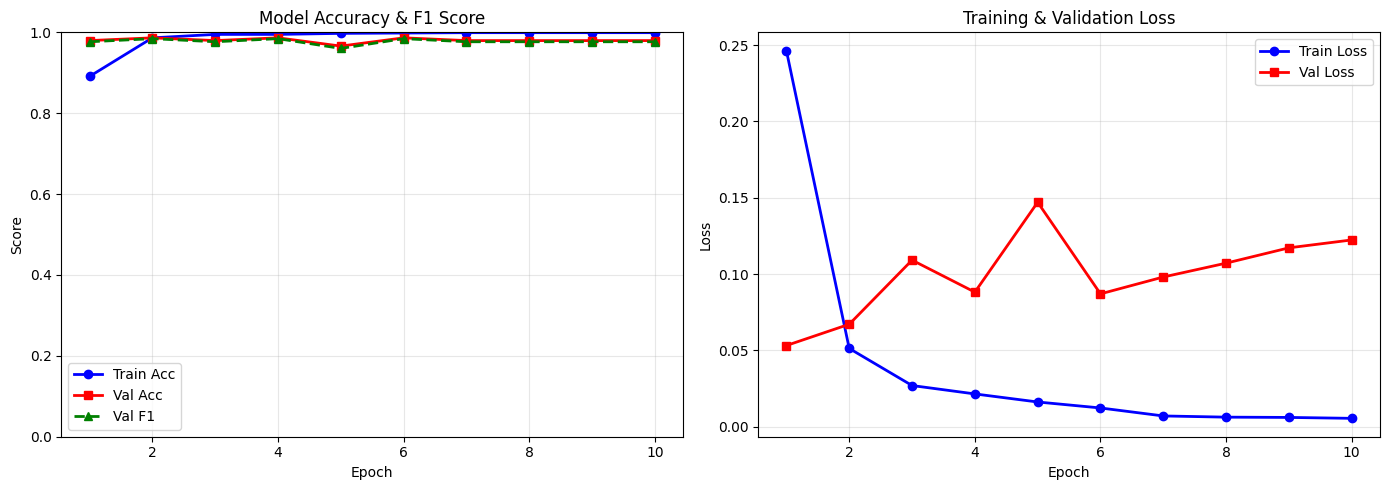


📊 Training metrics saved to 'training_metrics.csv'

FINAL TRAINING SUMMARY
Total epochs trained: 10
Best validation F1: 0.9844
Final train loss: 0.0054
Final train acc: 0.9991
Final val loss: 0.1223
Final val acc: 0.9796
Final val F1: 0.9767

✅ Good generalization! (gap: 1.96%)
CPU times: total: 7min 8s
Wall time: 7min 47s


In [7]:
%%time

# ============================================
# TRAINING LOOP WITH AUGMENTED DATA
# ============================================

from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ============================================
# VERIFY AUGMENTED DATA IS BEING USED
# ============================================
print("="*60)
print("VERIFYING AUGMENTED DATA IN TRAINING LOADER")
print("="*60)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Check class distribution in training
train_labels_check = train_dataset.tensors[2].cpu().numpy()
unique, counts = np.unique(train_labels_check, return_counts=True)
print("\n📊 Training class distribution (AUGMENTED):")
for label, count in zip(unique, counts):
    label_name = id2label[label]
    percentage = count/len(train_labels_check)*100
    print(f"  {label_name} ({label}): {count} samples ({percentage:.1f}%)")

if counts[1] > 108:  # Assuming netral is index 1
    print(f"\n✅ SUCCESS: Netral increased from 108 to {counts[1]} samples!")
else:
    print(f"\n⚠️ WARNING: Netral still at {counts[1]} samples. Augmentation may not have run.")
print("="*60)

# ============================================
# TRAINING FUNCTIONS
# ============================================

def train_one_epoch(model, dataloader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0.0
    total_examples = 0

    for batch in tqdm(dataloader, desc="Train", leave=False):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Manual loss
        loss = criterion(logits, labels)

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(logits, dim=-1)
        total_correct += (preds == labels).sum().item()
        total_examples += labels.size(0)

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc

def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0
    total_correct = 0.0
    total_examples = 0

    all_preds = []
    all_labels = []
    loss_fct = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval", leave=False):
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fct(logits, labels)

            total_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=-1)
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, avg_acc, macro_f1, np.array(all_preds), np.array(all_labels)

def plot_training_progress(epochs, train_losses, val_losses, train_accs, val_accs, val_f1s):
    """Create a figure with 2 subplots showing training progress"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Accuracy and F1
    ax1.plot(epochs, train_accs, 'b-', label='Train Acc', marker='o', linewidth=2, markersize=6)
    ax1.plot(epochs, val_accs, 'r-', label='Val Acc', marker='s', linewidth=2, markersize=6)
    ax1.plot(epochs, val_f1s, 'g-', label='Val F1', marker='^', linewidth=2, markersize=6, linestyle='--')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Score')
    ax1.set_title('Model Accuracy & F1 Score')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])
    
    # Plot 2: Loss
    ax2.plot(epochs, train_losses, 'b-', label='Train Loss', marker='o', linewidth=2, markersize=6)
    ax2.plot(epochs, val_losses, 'r-', label='Val Loss', marker='s', linewidth=2, markersize=6)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training & Validation Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================
# MAIN TRAINING LOOP
# ============================================

# Initialize lists to store metrics
train_losses = []
train_accs = []
val_losses = []
val_accs = []
val_f1s = []
epochs_completed = []

# Initialize early stopping variables
best_val_f1 = 0.0
patience = 8
patience_counter = 0

print("\n" + "="*60)
print("STARTING TRAINING WITH AUGMENTED DATA")
print("="*60)
print(f"Total training samples (augmented): {len(train_dataset)}")
print(f"Batch size: {train_loader.batch_size}")
print(f"Total batches per epoch: {len(train_loader)}")
print(f"Epochs: {epochs}")
print(f"Learning rate: {learning_rate}")
print("="*60)

for epoch in range(1, epochs + 1):
    print(f"\n====== Epoch {epoch}/{epochs} ======")
    
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, criterion)
    
    # Validate
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    epochs_completed.append(epoch)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # Overfitting check
    overfit_gap = train_acc - val_acc
    if overfit_gap > 0.15:
        print(f"OVERFITTING WARNING: Train-Val gap = {overfit_gap:.2%}")
    
    # Early stopping logic
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_indobert_sentiment.pt")
        patience_counter = 0
        print(f"✅ Model improved (F1: {val_f1:.4f}), saved.")
    else:
        patience_counter += 1
        print(f"⏳ No improvement for {patience_counter}/{patience} epochs")
        if patience_counter >= 3 and patience_counter < patience:
            # Reduce learning rate when plateauing
            for param_group in optimizer.param_groups:
                old_lr = param_group['lr']
                param_group['lr'] = old_lr * 0.5
                print(f"Learning rate reduced: {old_lr:.2e} -> {param_group['lr']:.2e}")
        if patience_counter >= patience:
            print(f"🛑 Early stopping at epoch {epoch}")
            break

print("\n" + "="*60)
print(f"✅ Training complete. Best Val F1: {best_val_f1:.4f}")
print("="*60)
# ============================================
# PLOT FINAL CHARTS
# ============================================
print("\n📊 Generating training progress charts...")
plot_training_progress(epochs_completed, train_losses, val_losses, train_accs, val_accs, val_f1s)

# ============================================
# SAVE METRICS TO CSV
# ============================================
metrics_df = pd.DataFrame({
    'epoch': epochs_completed,
    'train_loss': train_losses,
    'train_acc': train_accs,
    'val_loss': val_losses,
    'val_acc': val_accs,
    'val_f1': val_f1s
})
metrics_df.to_csv('training_metrics.csv', index=False)
print("\n📊 Training metrics saved to 'training_metrics.csv'")

# ============================================
# PRINT FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("FINAL TRAINING SUMMARY")
print("="*60)
print(f"Total epochs trained: {len(epochs_completed)}")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final train acc: {train_accs[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")
print(f"Final val acc: {val_accs[-1]:.4f}")
print(f"Final val F1: {val_f1s[-1]:.4f}")
print("="*60)

# Overfitting Assessment
final_gap = train_accs[-1] - val_accs[-1]
if final_gap > 0.15:
    print(f"\n⚠️ SIGNIFICANT OVERFITTING DETECTED!")
    print(f"   Train-Val accuracy gap: {final_gap:.2%}")
    print(f"   Suggested fixes:")
    print(f"   1. Increase dropout to 0.4 or 0.5")
    print(f"   2. Add more weight decay (0.02-0.05)")
    print(f"   3. Reduce model complexity")
    print(f"   4. Get more training data")
elif final_gap > 0.08:
    print(f"\n⚠️ Mild overfitting detected (gap: {final_gap:.2%})")
else:
    print(f"\n✅ Good generalization! (gap: {final_gap:.2%})")
print("="*60)

TEST SET EVALUATION (BINARY CLASSIFICATION)
Test Loss: 0.1394
Test Acc: 0.9728

Test F1 (Macro): 0.9684

Per-class Metrics: 
Label 0 (negatif): Precision = 0.977778, Recall = 0.9362, F1 = 0.9565, Support = 47
Label 1 (positif): Precision = 0.970588, Recall = 0.9900, F1 = 0.9802, Support = 100

Macro Precision: 0.9742
Macro Recall : 0.9631
Macro F1 : 0.9684

Classification Report:

              precision    recall  f1-score   support

     negatif       0.98      0.94      0.96        47
     positif       0.97      0.99      0.98       100

    accuracy                           0.97       147
   macro avg       0.97      0.96      0.97       147
weighted avg       0.97      0.97      0.97       147



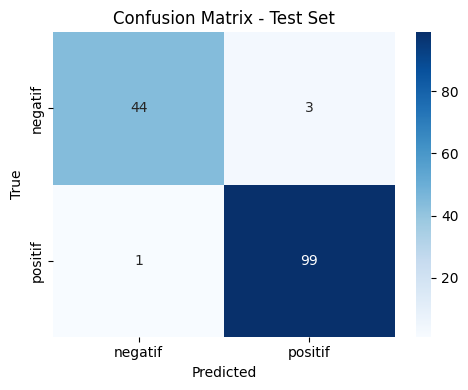

DIAGNOSTIC ANALYSIS

 Per-Class Accuracy:
 negatif: 93.62%
 positif: 99.00%

 Detailed Metrics:

   negatif
     True Positives: 44
     False Positives: 1
     False Negatives: 3
     Precision: 0.9778
     Recall: 0.9362
     F1: 0.9565

   positif
     True Positives: 99
     False Positives: 3
     False Negatives: 1
     Precision: 0.9706
     Recall: 0.9900
     F1: 0.9802

✅ Metrics disimpan ke: indobert_sentiment_metrics.csv

 Metrics Summary:
  label_id label_name  precision    recall  f1_score  support
0        0    negatif   0.977778  0.936170  0.956522       47
1        1    positif   0.970588  0.990000  0.980198      100
2    macro  macro_avg   0.974183  0.963085  0.968360      147
3  overall    overall   0.972789  0.972789  0.972789      147


In [13]:
# Evaluate TEST and Diagnostic
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

state_dict = torch.load("best_indobert_sentiment.pt", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

test_loss, test_acc, test_f1, y_pred, y_true = evaluate(model, test_loader)
print("="*60)
print("TEST SET EVALUATION (BINARY CLASSIFICATION)")
print("="*60)
print(f"Test Loss: {test_loss:.4g}")
print(f"Test Acc: {test_acc:.4g}\n")
print(f"Test F1 (Macro): {test_f1:.4g}\n")

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0, 1],
    average=None
)

print("Per-class Metrics: ")
for i, label_name in id2label.items():
    print(
        f"Label {i} ({label_name}): "
        f"Precision = {precision[i]:4f}, Recall = {recall[i]:.4f}, "
        f"F1 = {f1[i]:.4f}, Support = {support[i]}"
    )

# Macro avg
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro"
)

print(f"\nMacro Precision: {precision_macro:.4f}")
print(f"Macro Recall : {recall_macro:.4f}")
print(f"Macro F1 : {f1_macro:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=[id2label [i] for i in range(2)]))


#Confusion Matrix 2x2
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in range(2)],
    yticklabels=[id2label[i] for i in range(2)]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

# Diagnostic Analysis
print("="*60)
print("DIAGNOSTIC ANALYSIS")
print("="*60)

cm_normalized = cm.astype('float')/ cm.sum(axis=1)[:, np.newaxis]
print("\n Per-Class Accuracy:")
for i, label_name in id2label.items():
    print(f" {label_name}: {cm_normalized[i, i]:.2%}")


# Additional metrics
total_correct = np.trace(cm)
total_samples = np.sum(cm)
accuracy = total_correct / total_samples

# Precision, Recall, F1 per class
print("\n Detailed Metrics:")
for i, label_name in id2label.items():
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp

# Calculate precision with safety check
    if (tp + fp) > 0:
        precision_class = tp / (tp + fp)
    else:
        precision_class = 0
    
    # Calculate recall with safety check
    if (tp + fn) > 0:
        recall_class = tp / (tp + fn)
    else:
        recall_class = 0
    
    # Calculate F1 with safety check
    if (precision_class + recall_class) > 0:
        f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class)
    else:
        f1_class = 0

    print(f"\n   {label_name}")
    print(f"     True Positives: {tp}")
    print(f"     False Positives: {fp}")
    print(f"     False Negatives: {fn}")
    print(f"     Precision: {precision_class:.4f}")
    print(f"     Recall: {recall_class:.4f}")
    print(f"     F1: {f1_class:.4f}")

    
# Save Metrics to CSV

rows = []

for i in [0, 1]:
    rows.append(
        {
            "label_id" : i,
            "label_name" : id2label[i],
            "precision" : precision[i],
            "recall" : recall[i],
            "f1_score" : f1[i],
            "support" : int(support[i])
        }
    )

# Macro AVG
rows.append(
    {
        "label_id": "macro",
        "label_name": "macro_avg",
        "precision": precision_macro,
        "recall": recall_macro,
        "f1_score": f1_macro,
        "support": int(support.sum()),  # bisa juga len(y_true)
    }
)

# overall (accuracy) — kita isi semua kolom pakai test_acc biar gampang
rows.append(
    {
        "label_id": "overall",
        "label_name": "overall",
        "precision": test_acc,
        "recall": test_acc,
        "f1_score": test_acc,
        "support": int(len(y_true)),
    }
)

metrics_df = pd.DataFrame(rows)
metrics_path = "indobert_sentiment_metrics.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")

print(f"\n✅ Metrics disimpan ke: {metrics_path}")
print(f"\n Metrics Summary:")
print(metrics_df)

In [14]:
# Save Model and Tokenizer in HuggingFace folder

SAVE_DIR = "indobert-sentiment-3class"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model & Tokenizer saved to {SAVE_DIR} folder")

Model & Tokenizer saved to indobert-sentiment-3class folder


In [15]:
# Save Analysis (Test Predict) result into CSV

# Retrieve test rows from df_gold based on index split
df_test_eval = df_gold.iloc[test_idx].copy().reset_index(drop=True)

# Make sure y_true and y_pred has the same length as test row count
print("Len df_test_eval:", len(df_test_eval))
print("Len y_true      :", len(y_true))
print("Len y_pred      :", len(y_pred))

# Create result DataFrame
results_df = pd.DataFrame({
    "text": df_test_eval["content"].values,
    "true_label_id": y_true,
    "true_label": [id2label[int(i)] for i in y_true],
    "pred_label_id": y_pred,
    "pred_label": [id2label[int(i)] for i in y_pred]
})

# Add column is pred True or False
results_df["correct"] = results_df["true_label_id"] == results_df["pred_label_id"]

# Save CSV to folder
out_path = "/working"
results_df.to_csv(out_path, index=False, encoding="utf-8")

print("Analysis Test results saved at: ", out_path)
results_df.head()

Len df_test_eval: 147
Len y_true      : 147
Len y_pred      : 147
Analysis Test results saved at:  /working


,text,true_label_id,true_label,pred_label_id,pred_label,correct
0,siip,1,positif,1,positif,True
1,"sangat praktis saat transaksi,apalagi urusan t...",1,positif,1,positif,True
2,ok,1,positif,1,positif,True
3,"Wonder by BNI mantaps,...pokoknya mantaps.lebi...",1,positif,1,positif,True
4,baik,1,positif,1,positif,True


In [18]:
# Take a raw sample from the original DataFrame
sample_idx = 3
print("Text in CSV      :", df_test_eval["content"].iloc[sample_idx])
print("Label in CSV     :", df_test_eval["label"].iloc[sample_idx]) # To check real label column

# Compare with one fetched by evaluation variable
print("Label ID (y_true):", y_true[sample_idx])
print("Label name       :", id2label[y_true[sample_idx]])

Text in CSV      : Wonder by BNI mantaps,...pokoknya mantaps.lebih mudah bertransaksi..... semoga Bank BNI lebih maju dan sukses terus
Label in CSV     : 3
Label ID (y_true): 1
Label name       : positif


In [ ]:
from google_play_scraper import reviews_all, reviews, Sort
import pandas as pd
from pathlib import Path
import os
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

# Config
APP_ID = "id.bni.wondr"
SAVE_FILE = "all_reviews_wondr.csv" # raw scrapping results
MASTER_PATH ="working/total_dataset.csv" # combined dataset of pseudo+gold
MODEL_DIR = "indobert-sentiment-3class" # model teacher

# SCRAPING : auto_update()

def load_existing():
    """Load old scaping data from SAVE_FILE if exists, if not DF empty"""
    if Path(SAVE_FILE).exists():
        df = pd.read_csv(SAVE_FILE)
        expected_cols = ["reviewId", "content", "at"]
        for col in expected_cols"
        if col not in df.columns:
            df[col] = None
        df = df[expected_cols].copy()
        df["reviewId"] = df["reviewId"].astype(str)
        return df
    else:
        return pd.DataFrame(columns=["reviewId","content","at"])

def fetch_all_reviews():
    """Retrieve ALL reviews from Play Store (used first time)"""
    print("[FULL] Retrieving ALL reviews from Play Store")
    raw = reviews_all(
        APP_ID,
        lang="id",
        country="id",
    )
    df = pd.DataFrame(raw)
    df = df[["reviewId", "content", "at"]].copy()
    df["reviewId"] = df["reviewId"].astype(str)
    return df

def fetch_latest(limit=2000): #Default is increased to 2000
    """Retrieve latest 'limit' reviews from Play Store."""
    print(f"[INCREMENTAL] retrieving {limit} latest reviews from Play Store..... ")
    raw, _ = reviews(
        APP_ID,
        lang="id",
        country="id",
        sort=Sort.NEWEST,
        count=limit
    )
    df = pd.DataFrame(raw)
    df = df[["reviewId","content","at"]].copy()
    df["reviewId"] = df["reviewId"].astype(str)
    return df



# DASHBOARD

In [1]:
pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.2 MB 9.5 MB/s eta 0:00:01
   --------- ------------------------------ 2.1/9.2 MB 7.8 MB/s eta 0:00:01
   ------------------- -------------------- 4.5/9.2 MB 7.7 MB/s eta 0:00:01
   -------------------------- ------------- 6.0/9.2 MB 7.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.2 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.2 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 7.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   --------------------------------------- 797.6/797.6 kB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.3 MB 7.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 6.0 MB/s eta 0:00:02
   ------------- -------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
